In [ ]:
import numpy as np
from matplotlib import pyplot as plt

from loki.libloki.configs import PulsarSearchConfig
from loki.libloki.plans import FFAPlanFourier
from loki.libloki.prune import EPMultiPassFourier
from pyloki.config import ParamLimits
from pyloki.detection import thresholding
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


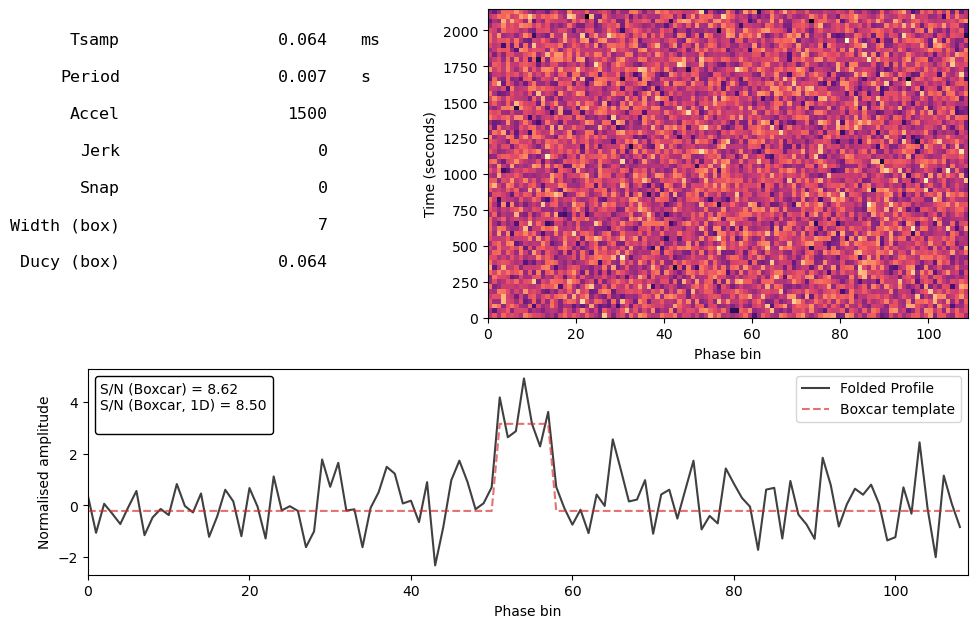

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 1500
nsamps = 2**25
mod_kwargs = {"acc": accel}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=8.5,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_taylor((140.0, 145.0), (-2500.0, 2500.0))
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 16384
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=2,
    nthreads=8,
    ducy_max=0.2,
    wtsp=1.1,
    use_fourier=True,
)
plan = FFAPlanFourier(search_cfg)
branching_pattern = plan.get_branching_pattern()
branching_pattern

Param limits: [[-2500.  2500.]
 [  140.   145.]]


array([8.        , 3.        , 2.        , 3.        , 1.        ,
       1.        , 2.        , 3.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 2.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       2.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 2.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

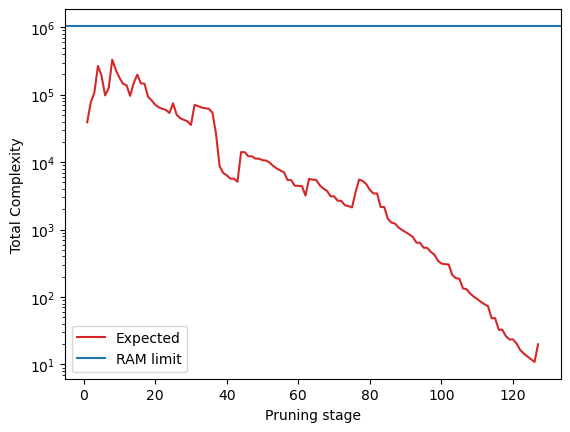

In [4]:
thresholds = np.array([2.1, 2.5, 2.6, 2.5, 2.7, 3. , 3.1, 2.9, 3.1, 3.1, 3.1, 2.9, 3.2,
       3.5, 3.6, 3.6, 3.2, 3.7, 3.6, 3.6, 3.5, 3.4, 3.3, 3.4, 3.9, 4. ,
       3.9, 3.8, 3.7, 3.8, 3.5, 3.6, 3.6, 3.5, 3.4, 3.6, 4.1, 4.5, 4.5,
       4.4, 4.4, 4. , 4.3, 4.3, 4. , 4.3, 4. , 4.2, 4. , 4.1, 4. , 4.1,
       4.2, 4.2, 4.2, 4.2, 4.4, 4. , 4.4, 4.2, 4.1, 4.5, 4.5, 4.4, 4.3,
       4.5, 4.5, 4.5, 4.6, 4.4, 4.6, 4.4, 4.6, 4.5, 4.5, 4.6, 4.4, 4.5,
       4.6, 4.7, 4.7, 4.4, 4.9, 4.5, 5. , 5. , 4.9, 5. , 5. , 5. , 5. ,
       5. , 5.1, 4.9, 5.1, 4.9, 5.1, 5.1, 5.2, 5.2, 5.1, 5. , 5.3, 5.3,
       5.2, 5.4, 5.3, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.6, 5.3, 5.7, 5.3,
       5.7, 5.7, 5.3, 5.7, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=8.5,
    ducy_max=0.2,
    wtsp=1.5,
)
x = np.arange(1, len(branching_pattern) + 1)
nparam_vol = plan.ncoords[-1]
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**20, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [5]:
ep_manager = EPMultiPassFourier(
    search_cfg,
    thresholds,
    n_runs=32,
    max_sugg=2**20,
    batch_size=1024,
    poly_basis="taylor",
    show_progress=False,
)
ep_manager.execute(
    tim_data.ts_e,
    tim_data.ts_v,
    outdir="pruning_results/accel_test/",
    file_prefix="test_accel",
)

[2026-04-09 16:04:56.661] [info] EPMultiPass: Initializing with FFA
[2026-04-09 16:04:56.700] [info] P-FFA [16384, 1, 20, 2, 33] -> [128, 2, 2684, 2, 33]
[2026-04-09 16:04:56.700] [info] FFA Memory Usage: 0.68 GB + 0.00 GB (coords)
[2026-04-09 16:04:57.833] [info] Starting Pruning for 32 runs, with 8 threads
[2026-04-09 16:04:57.850] [info] Pruning run 008: Memory Usage: 0.59 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:04:57.850] [info] Pruning run 004: Memory Usage: 0.59 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:04:57.851] [info] Pruning run 004: initialized
[2026-04-09 16:04:57.851] [info] Pruning run 008: initialized
[2026-04-09 16:04:57.852] [info] Pruning run 012: Memory Usage: 0.59 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:04:57.852] [info] Pruning run 024: Memory Usage: 0.59 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:04:57.852] [info] Pruning run 028: Memory Usage: 0.59 GB (tree) + 0.02 GB (workspace)
[2026-04-09 16:04:57.852] [info] Pruning run 012: initialized

In [6]:
result_file = "pruning_results/accel_test/test_accel_pruning_nstages_128_results.h5"
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, run_id=None))

True params, a: 1500.000, f: 142.8571428571
Top candidates:
dparams: daccel: 0.2094947209, dfreq: 1.455191523e-05
Run: 016_05, S/N: 8.37, accel: 1500.00, freq: 142.857140
Run: 098_25, S/N: 8.36, accel: 1499.97, freq: 142.857157
Run: 016_05, S/N: 8.32, accel: 1500.00, freq: 142.857155
Run: 098_25, S/N: 8.28, accel: 1499.97, freq: 142.857142
Run: 098_25, S/N: 7.80, accel: 1499.97, freq: 142.857113
Run: 102_26, S/N: 7.80, accel: 1499.88, freq: 142.857120
Run: 102_26, S/N: 7.79, accel: 1499.88, freq: 142.857134
Run: 098_25, S/N: 7.78, accel: 1499.97, freq: 142.857128
Run: 020_06, S/N: 7.75, accel: 1499.91, freq: 142.857144
Run: 020_06, S/N: 7.68, accel: 1499.91, freq: 142.857159


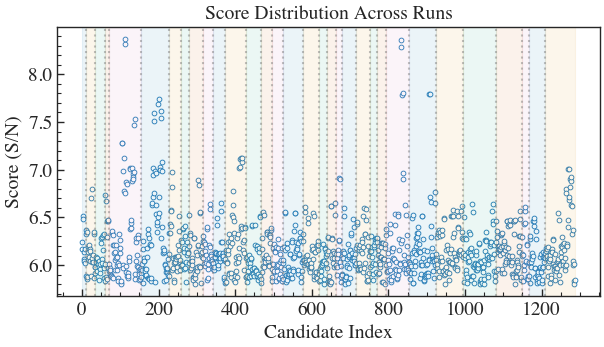

In [7]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

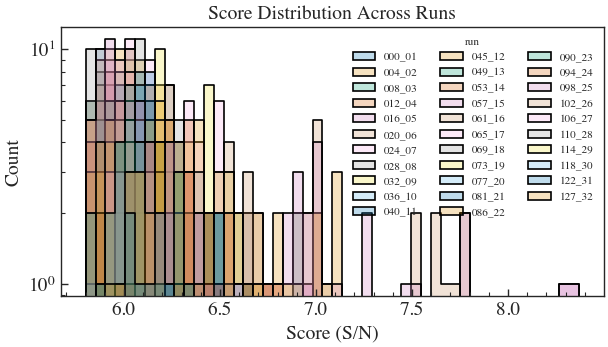

In [8]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

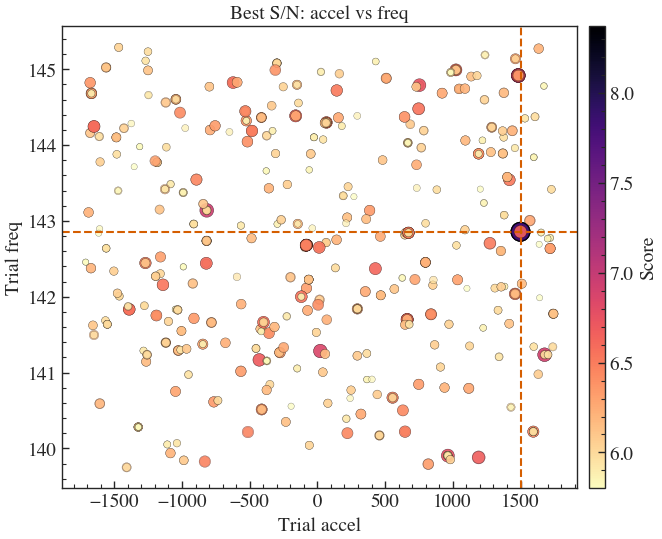

In [9]:
pgram.plot_correlation(
    "accel",
    "freq",
    true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq},
    run_id=None,
)
plt.show()

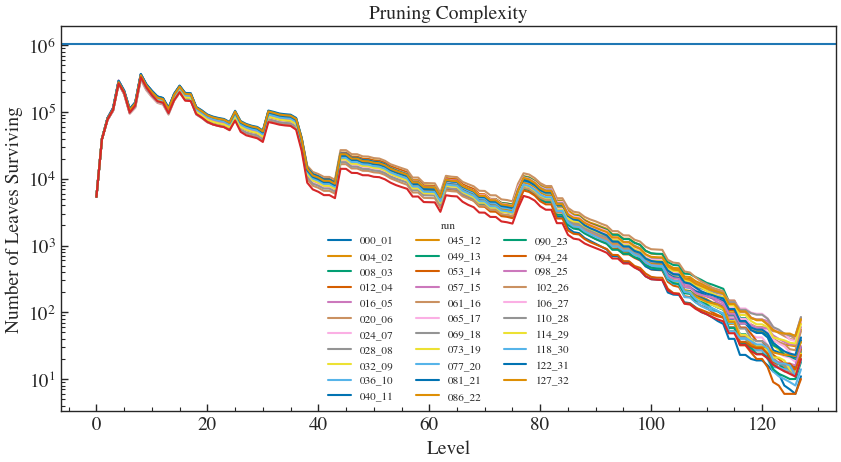

In [10]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(
    x,
    np.concatenate(([1], thresh_state.get_info("complexity"))) * nparam_vol,
    label="Expected",
    c="tab:red",
)
ax_list[0].axhline(2**20, label="RAM limit", c="tab:blue")
plt.show()